In [42]:
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt

import sys

#from ham_creation import create_hex_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis, load_data
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

hbar = 0.6582
a_l = 0.24595
a_cc = a_l/3**0.5


M = 0.0
t = 2.7
vf  = 3*a_cc*abs(t)/(2*hbar)

# Matplotlib stuff
plt.rcParams.update({'font.size': 11})  # Match REVTeX default 10pt
plt.rcParams['pdf.fonttype'] = 42  # Save text as TrueType (editable) instead of paths
plt.rcParams['ps.fonttype'] = 42   # Same for PostScript
plt.rcParams['text.usetex'] = True  # Keep LaTeX rendering
plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    'font.size': 11,              # Tamaño base general (afecta a textos libres)
    'figure.titlesize': 18,       # Título principal de la figura (suptitle)
    'axes.titlesize': 12,         # Título de cada gráfico (title)
    'axes.labelsize': 12,         # Etiquetas de los ejes (xlabel e ylabel)
    'xtick.labelsize': 11,        # Números/marcas del eje X
    'ytick.labelsize': 11,        # Números/marcas del eje Y
    'legend.fontsize': 11,        # Texto de los elementos de la leyenda
    'legend.title_fontsize': 11   # Título de la leyenda
})

# Configuración exclusiva para grosores y tamaños de elementos visuales
plt.rcParams.update({
    # 1. Líneas y Marcadores (El contenido de tus gráficos)
    'lines.linewidth': 3,          # Grosor de las líneas de los gráficos
    'lines.markersize': 10,           # Tamaño de los puntos/marcadores
    'lines.markeredgewidth': 1.5,    # Grosor del borde de los marcadores

    # 2. Gráficos de barras y formas (Patches)
    #'patch.linewidth': 1.2,          # Grosor del borde de las barras (plt.bar) o rectángulos

    # 3. El marco del gráfico (Ejes / Spines)
    #'axes.linewidth': 1.5,           # Grosor de la línea del recuadro exterior del gráfico

    # 4. La cuadrícula (Grid)
    'grid.linewidth': 0.8,           # Grosor de las líneas de la cuadrícula de fondo

    # 5. Las pequeñas marcas de los ejes (Ticks)
    'xtick.major.size': 6,           # Qué tan largas son las marcas del eje X
    'xtick.major.width': 1.5,        # Qué tan gordas son las marcas del eje X
    'ytick.major.size': 6,           # Qué tan largas son las marcas del eje Y
    'ytick.major.width': 1.5         # Qué tan gordas son las marcas del eje Y
})


In [43]:
# ------------------------------------------------------------------------------
#### PARAMETERS OF THE MODEL
out_file_loc = ''
## PHYSICAL
# Type of light               
modifier_id = 'circln'
# Hamiltonian type
type_ham = 'basic'
# Parameters of the ham (only read if hbn)
ham_params = 0.5
# Energy in pulse                        
E = 1.0
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.01
# Intensity param     (no units)
gamma_list = np.linspace(0.000, 0.025, 6)                   

## SIMULATION
# Size of hamiltonian
N_pot = 19
N = 2**N_pot
# Amount of periods to be simulated
n_periods = 500
# Simulation steps per period
steps_per_T = 1000
# Amount of measures per period
meas_per_T = 16
N_measures = meas_per_T*n_periods
# Amount of random vectors used in calculation
N_random_vector = 5
# Momenta
M = int(np.sqrt(N))
#M = 362

## RESULT ANALYSIS
hE_reps = 2



5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...


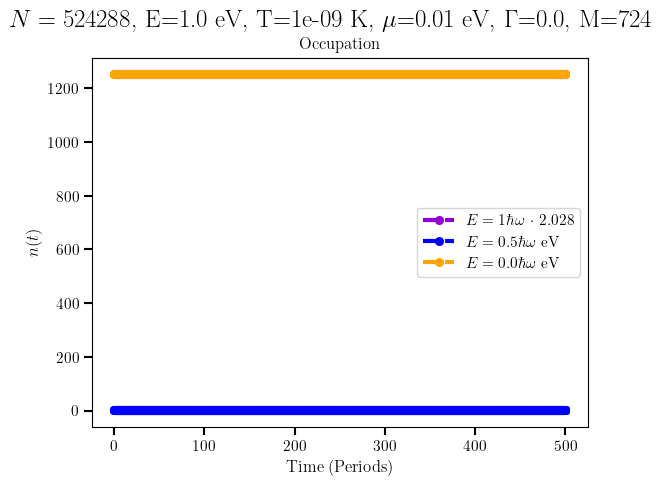

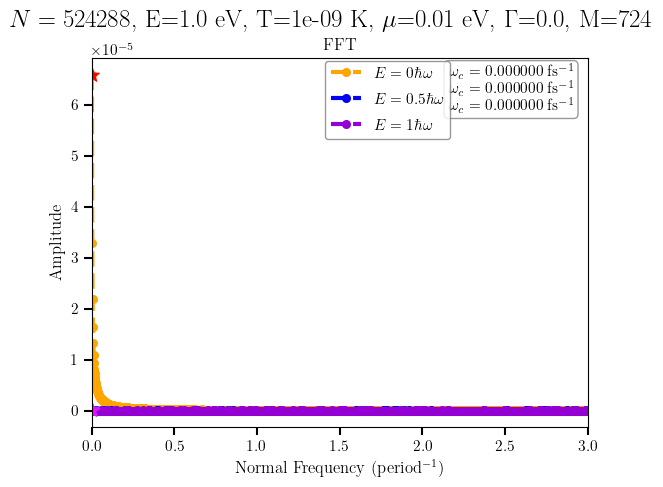

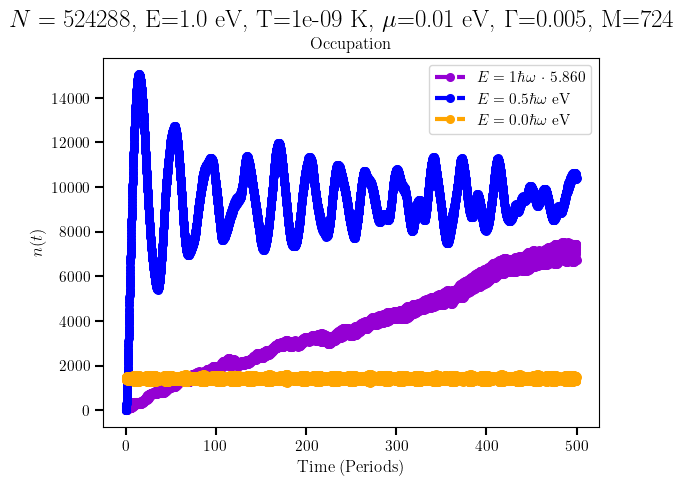

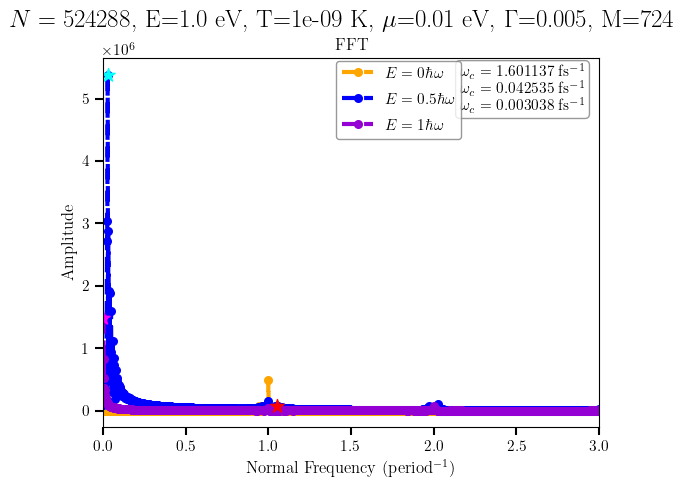

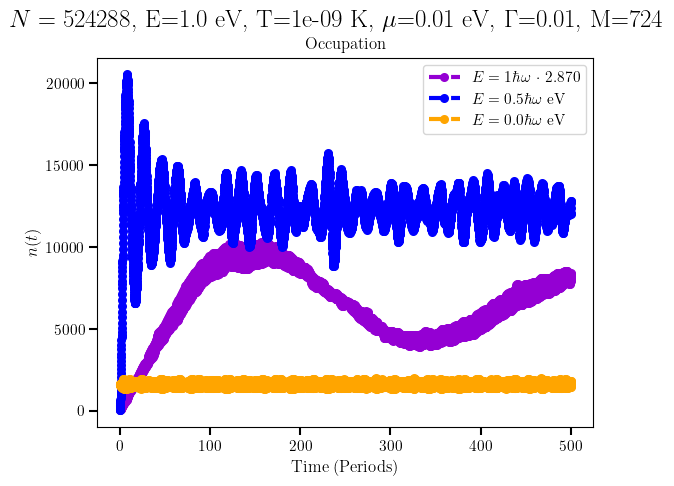

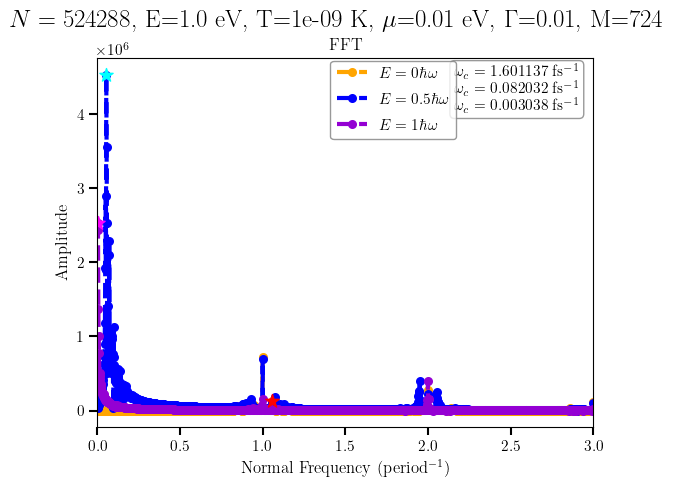

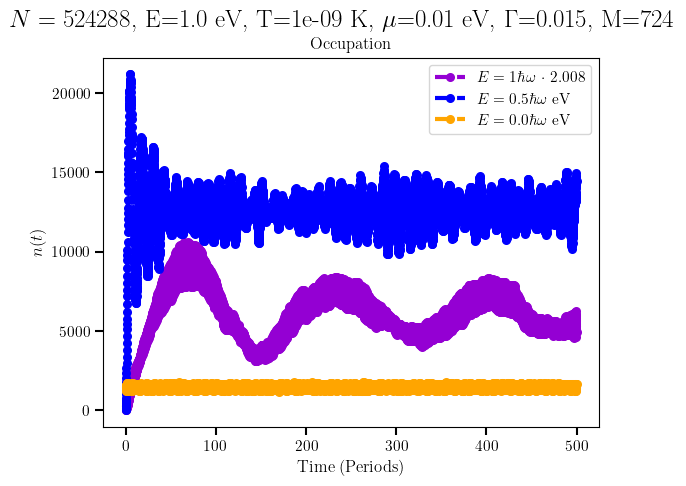

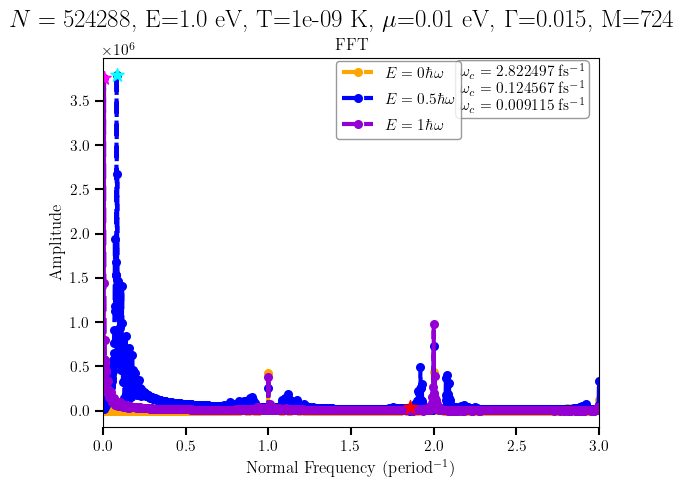

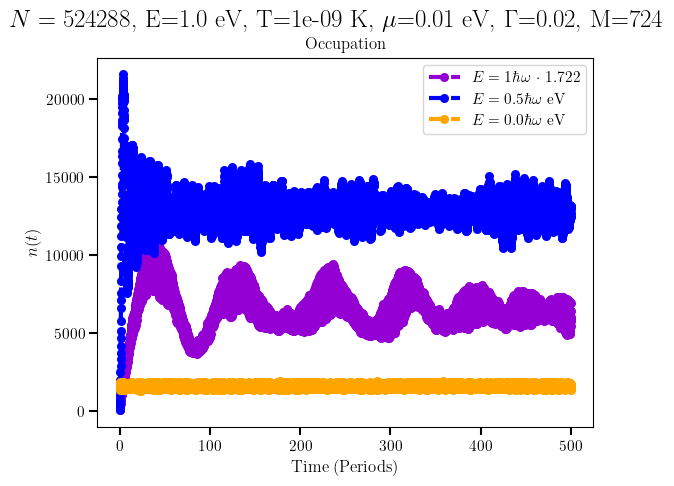

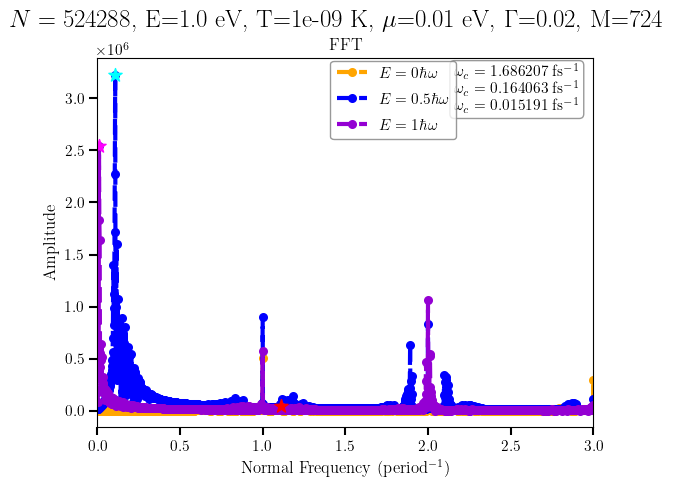

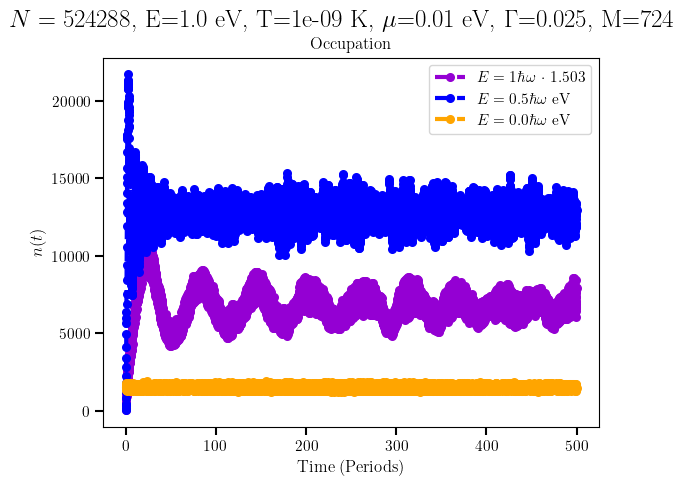

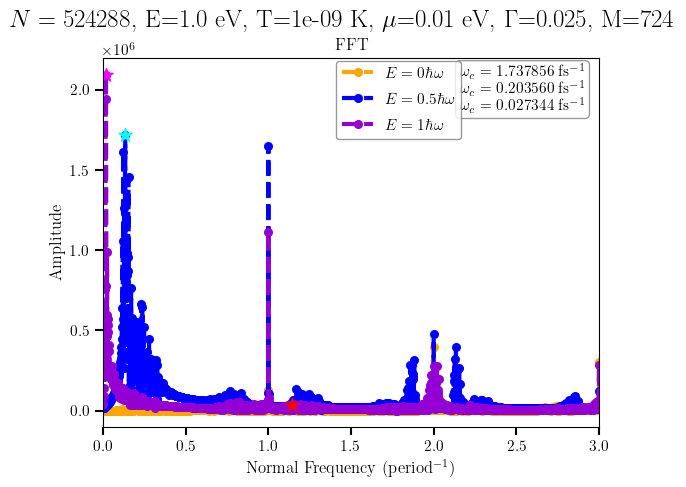

In [44]:
## RESULT ANALYSIS
## CALCULATED PARAMS


char_freq = np.zeros((len(gamma_list), 2*hE_reps + 1))
'''
timeframe_intensity_list = [(0.000, 100, 4, 1.0),
                            (0.005, 500, 4, 1.0),
                            (0.010, 200, 8, 1.0),
                            (0.015, 150, 8, 1.0),
                            (0.020, 100, 16, 1.0),
                            (0.025, 100, 16, 1.0),
                            (0.030, 80, 24, 1.0),
                            (0.035, 80, 24, 1.0),
                            (0.040, 50, 32, 1.0),
                            (0.045, 50, 32, 1.0),
                            (0.050, 50, 32, 1.0)]
'''
for (g, gamma) in enumerate(gamma_list):
    if M == 0:
        M = int(np.sqrt(N))
    #n_periods, meas_per_T, E = timeframe_intensity_list[g][1:]

    # Parameters of the laser
    w = E/hbar
    T = 2*np.pi/w    
    t_vec = np.linspace(0,n_periods*T , steps_per_T*n_periods)   
    # Amount of half multiples of E where the occupation is obtained
    
    # Broadening in the energies
    N_measures = meas_per_T*n_periods
    t_vec_measures = np.linspace(0, n_periods*T, N_measures)
    hE_list = [hE*E/2 for hE in range(-hE_reps, hE_reps+1)]
    color_list = ['olivedrab', 'red', 'orange', 'blue', 'darkviolet']
    # Names of file and info on graphs
    folder_name = f'{modifier_id}/G={gamma:.3f}_E={float(E)}_Temp={Temp}_mu={mu:.2f}/N={N_pot}_M={M}_R={N_random_vector}_nT={n_periods}_measT={meas_per_T}_stT={steps_per_T}'
    fig_title_info = f'$N={{{2**N_pot}}}$, E={E} eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}'

    # Loading the info in the .npy files
    EF_list, n_E_list, dos_list, dosn_list = load_data(modifier_id, N_pot, E, Temp, mu, gamma, M, N_random_vector, n_periods, meas_per_T, steps_per_T, type_ham, ham_params, R=None)

    # Getting the characteristic period of each system
    occ_drop_list, fourier_occ, freq, char_freq[g], max_freq_ind = frequency_analysis(EF_list, dosn_list, hE_list, t_vec_measures, T)
    # --------------------------------------------------------------------------
    # OCCUPATION(time) GRAPH
    # General figure to contain all important data
    fig, ax = plt.subplots()
    reescale = np.max(occ_drop_list[3]) / np.max(occ_drop_list[4]) / 2
    ax.plot(np.array(t_vec_measures)/T, occ_drop_list[4]*reescale, c='darkviolet', 
            marker='.', ls='--', label=f"$E=1\\hbar\\omega$ $\\cdot$ {reescale:.3f}")
    ax.plot(np.array(t_vec_measures)/T, occ_drop_list[3], c='blue', 
            marker='.', ls='--', label=f"$E=0.5\\hbar\\omega$ eV")
    ax.plot(np.array(t_vec_measures)/T, occ_drop_list[2], c='orange', 
            marker='.', ls='--', label=f"$E=0.0\\hbar\\omega$ eV")
    ax.set_xlabel('Time (Periods)')
    ax.set_ylabel('$n(t)$')
    ax.set_title(fr'Occupation')
    fig.suptitle(fig_title_info)
    ax.legend()

    # --------------------------------------------------------------------------
    # FREQUENCY ANALYSIS OF THE RESULTS
    # General figure
    max_freq = min(3, freq[-1]*T/(2*np.pi))
    props = dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8)

    fig, ax = plt.subplots()
    ax.plot(freq*T/(2*np.pi), fourier_occ[2], c='orange', marker='.', ls='--', 
            label=f'$E = 0\\hbar\\omega$')
    ax.plot(freq*T/(2*np.pi), fourier_occ[3], c='blue', marker='.', ls='--', 
            label=f'$E = 0.5\\hbar\\omega$')
    ax.plot(freq*T/(2*np.pi), fourier_occ[4], c='darkviolet', marker='.', ls='--', 
            label=f'$E = 1\\hbar\\omega$')
    # Markers of max frequencies
    ax.scatter(freq[max_freq_ind[2]]*T/(2*np.pi), fourier_occ[2, max_freq_ind[2]], color='red',
            marker='*', zorder=2)
    ax.scatter(freq[max_freq_ind[3]]*T/(2*np.pi), fourier_occ[3, max_freq_ind[3]], color='cyan',
            marker='*', zorder=2)
    ax.scatter(freq[max_freq_ind[4]]*T/(2*np.pi), fourier_occ[4, max_freq_ind[4]], color='magenta',
            marker='*', zorder=2)
    #ax.vlines([range_search], 0, np.max(fourier_occ), ls='-.', color='gray')
    ax.set_xlim(0, max_freq)
    wc_text = f'$\\omega_c = {char_freq[g, 2]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[g, 3]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[g, 4]:.6f}$ fs$^{{-1}}$'
    ax.text(0.72, 0.98, wc_text, transform=ax.transAxes,
            verticalalignment='top', bbox=props)
    ax.legend(loc=(0.47, 0.7815), labelspacing=0.8, edgecolor='grey')
    ax.set_xlabel('Normal Frequency (period$^{-1}$)')
    ax.set_ylabel('Amplitude')
    ax.set_title('FFT')
    fig.suptitle(fig_title_info)
    
    



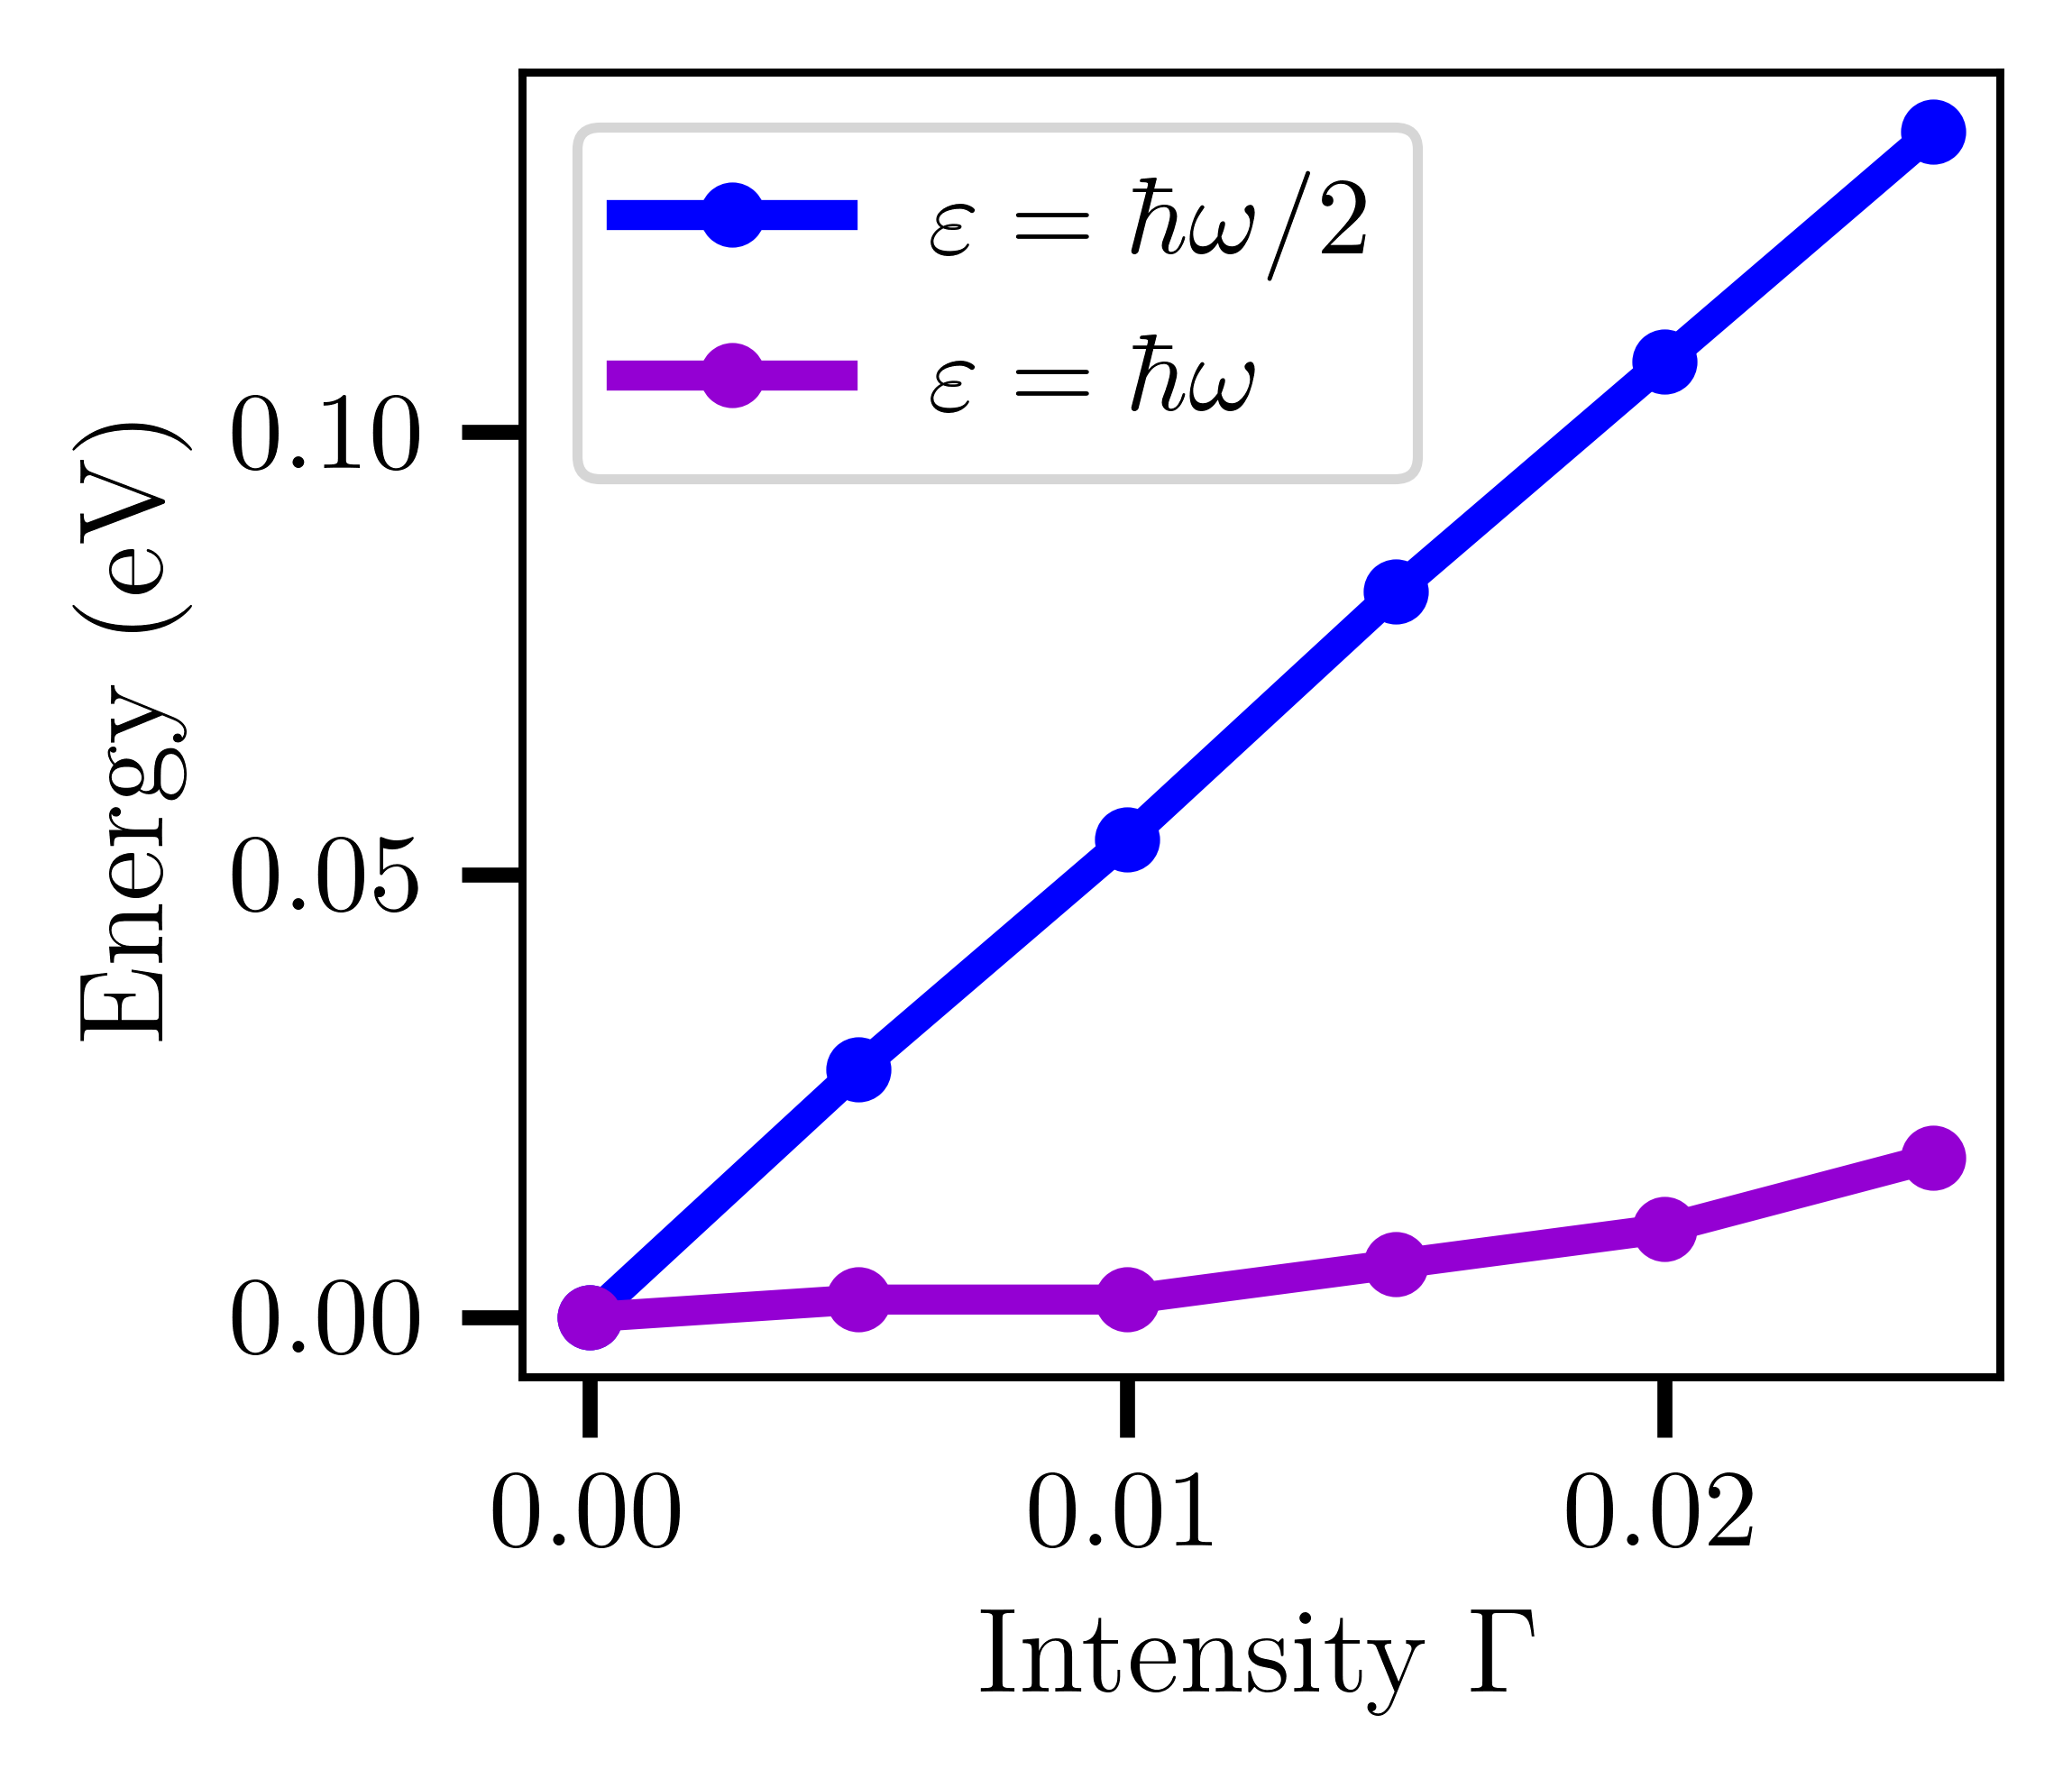

In [45]:
# Final plot of the gammas
fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')
#ax.plot(gamma_list, char_freq[:,2], ls='--', c=color_list[2], marker='.',
#        label=f'$E = \\mu$ eV')
ax.plot(gamma_list, char_freq[:,3]*hbar, ls='-', c='blue', marker='.', label=f'$\\varepsilon = \\hbar\\omega/2$')
ax.plot(gamma_list, char_freq[:,4]*hbar, ls='-', c='darkviolet', marker='.', label=f'$\\varepsilon =\\hbar\\omega$')
ax.set_xlabel(f'Intensity $\\Gamma$')
ax.set_ylabel('Energy (eV)')
ax.legend()
#ax.set_xticks(gamma_list)
#fig.suptitle(f'$N={{{2**N_pot}}}$, $\\hbar\\omega$={E} eV, Temp={Temp} K, $\\mu$={mu} eV')
fig.savefig('Graphs/neq_freqs.pdf')

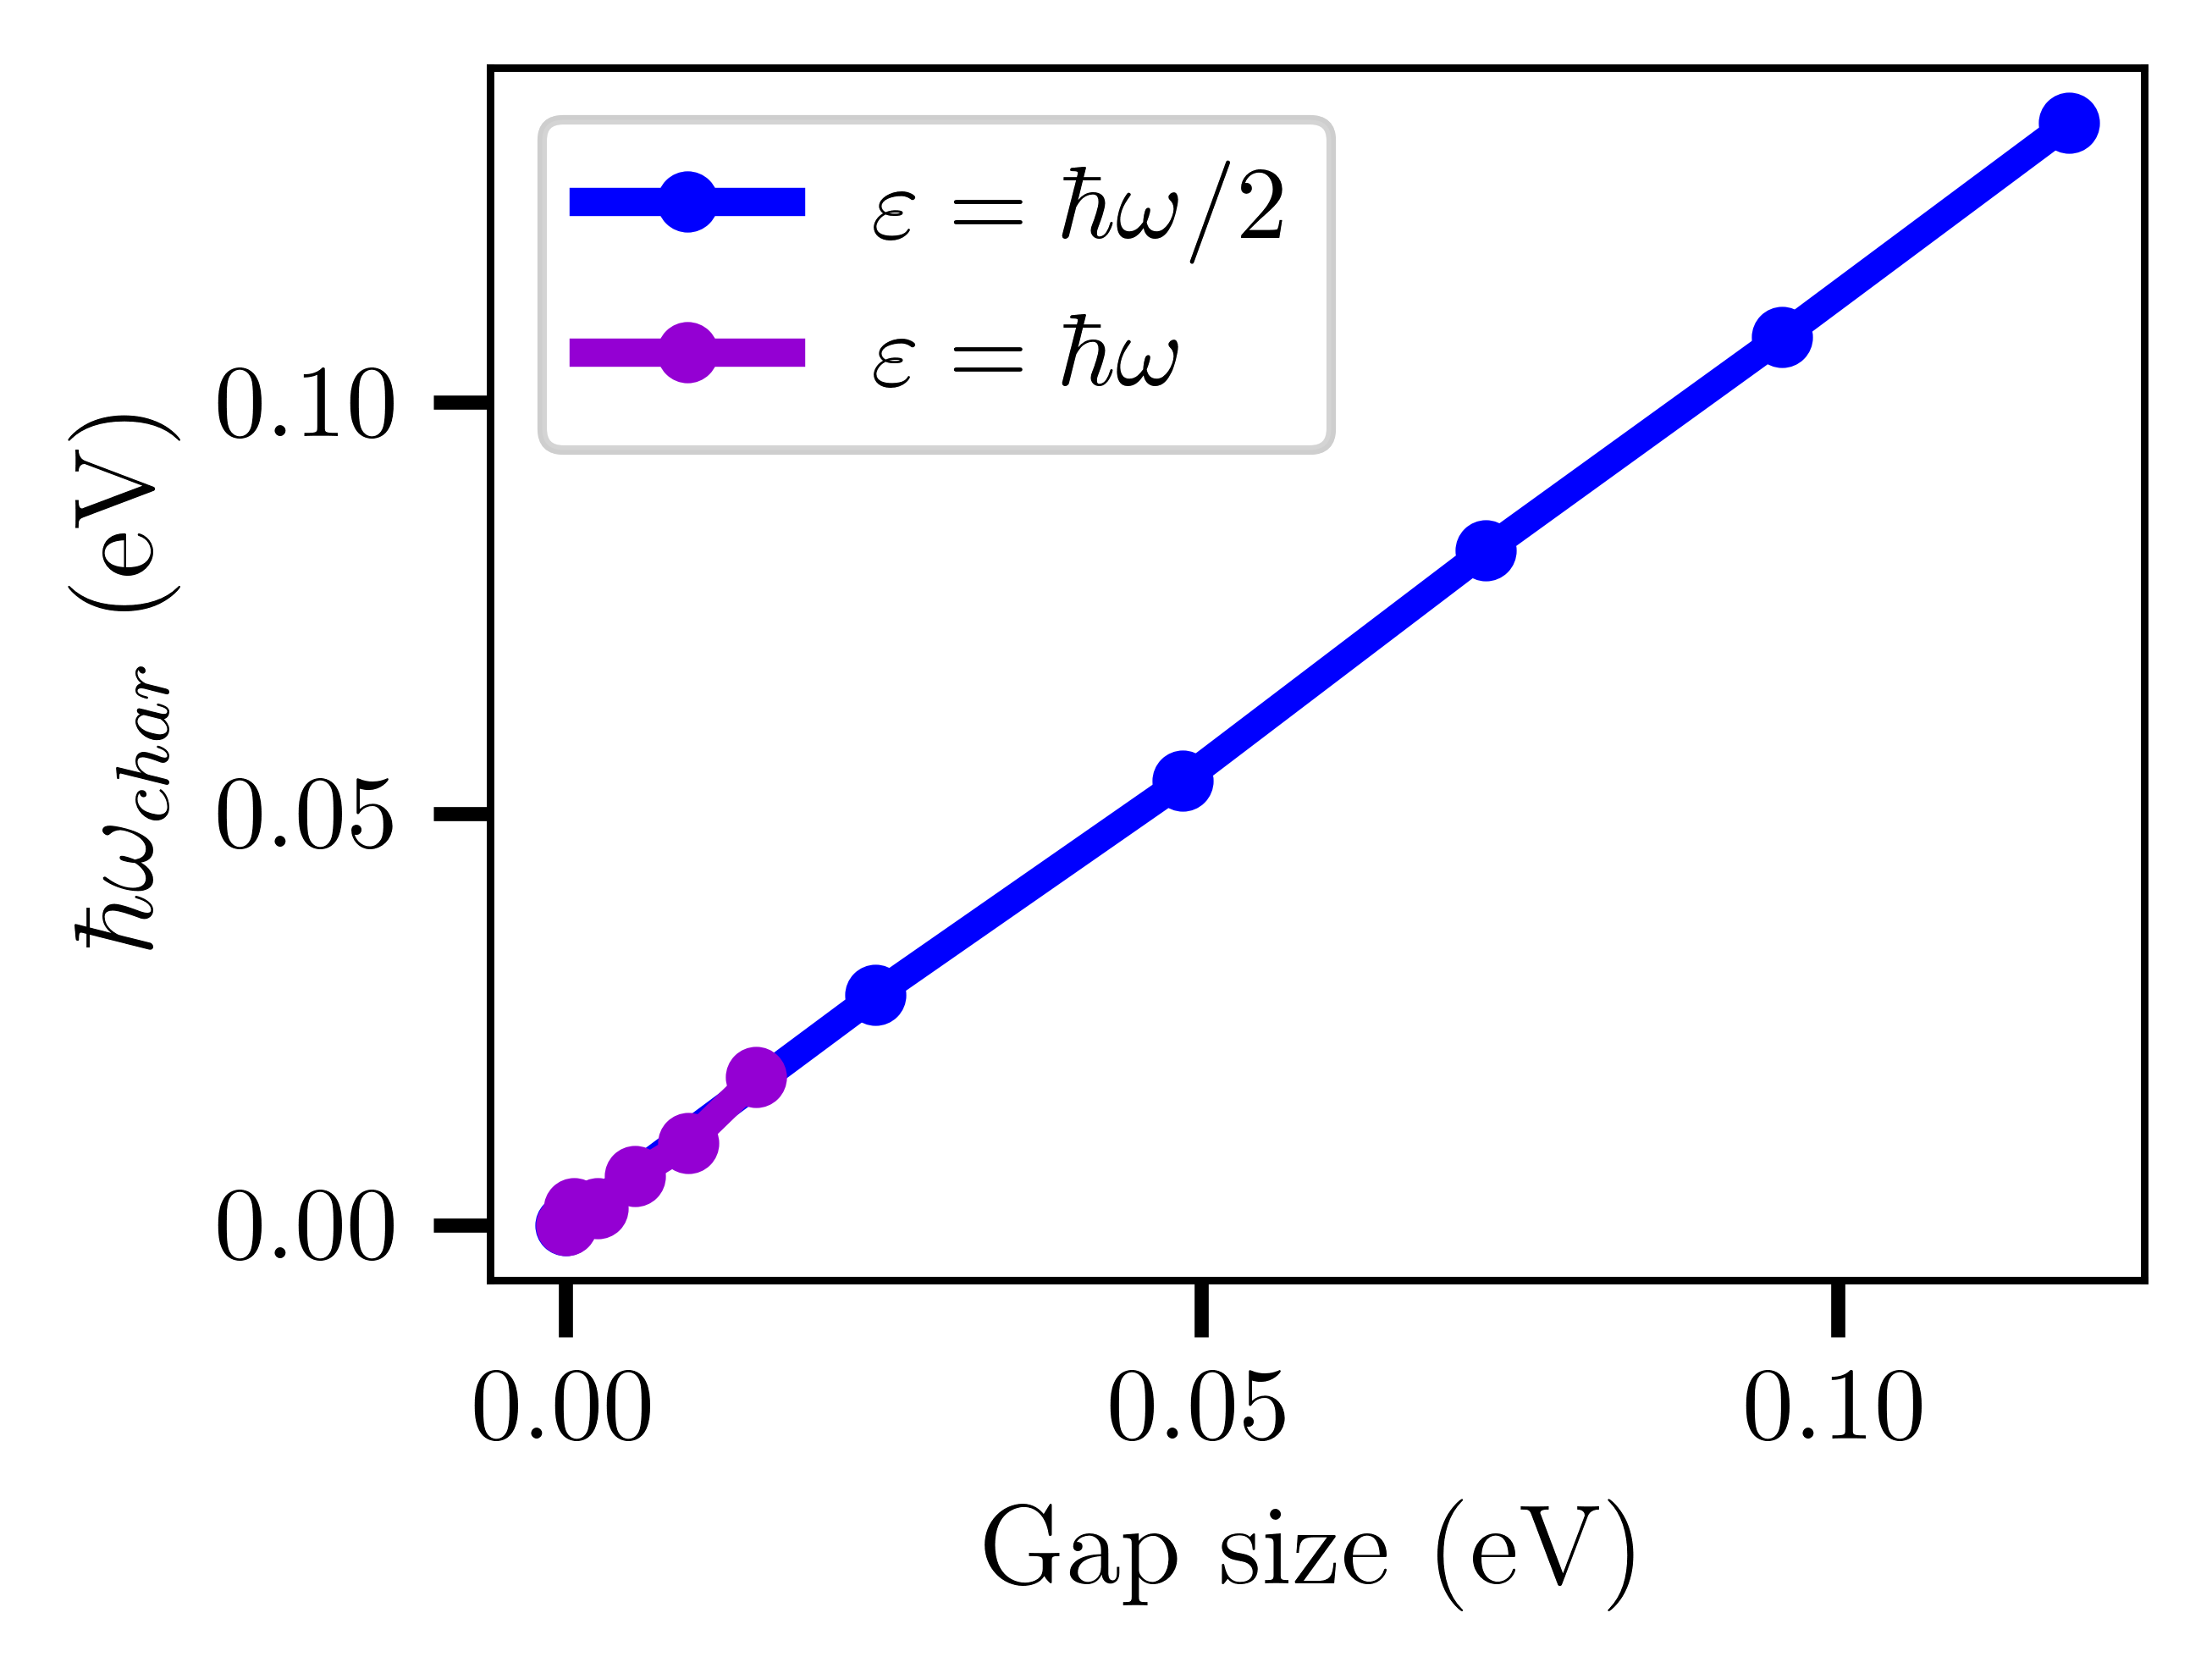

In [46]:

#%% Fitting to see if a relation is even possible
# Importing the results from Floquet
n_rep = 4
gamma_fl = np.load(f'band_gaps/{modifier_id}_real/hw={E}_nrep={n_rep}/gamma_fl.npy')
gap0_fl = np.load(f'band_gaps/{modifier_id}_real/hw={E}_nrep={n_rep}/gap0.npy')
gap1_fl = np.load(f'band_gaps/{modifier_id}_real/hw={E}_nrep={n_rep}/gap1.npy')
gap2_fl = np.load(f'band_gaps/{modifier_id}_real/hw={E}_nrep={n_rep}/gap2.npy')

# Seeing which indexes are used in the other results
used_inds = []
for (i, g_fl) in enumerate(gamma_fl):
    if g_fl in gamma_list:
        used_inds.append(i)

# Applying the results
gamma_fl = gamma_fl[used_inds]
gap0_fl = gap0_fl[used_inds]
gap1_fl = gap1_fl[used_inds]
gap2_fl = gap2_fl[used_inds]

# Fitting of the curve
from scipy.stats import linregress
# GAP1 REGRESSION
lin_reg1 = linregress(gap1_fl, char_freq[:,3]*hbar)
slope1 = lin_reg1.slope
intercept1 = lin_reg1.intercept
R2_1 = lin_reg1.rvalue**2
test_gaps1 = np.linspace(np.min(gap1_fl), np.max(gap1_fl), 100)
lin_predict1 = slope1*test_gaps1 + intercept1

# GAP2 REGRESSION
lin_reg2 = linregress(gap2_fl, char_freq[:,4]*hbar)
slope2 = lin_reg2.slope
intercept2 = lin_reg2.intercept
R2_2 = lin_reg2.rvalue**2
test_gaps2 = np.linspace(np.min(gap2_fl), np.max(gap2_fl), 100)
lin_predict2 = slope2*test_gaps2 + intercept2

# Graph of the results
fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')

# IMPORTANTE: Nota la coma ',' después del nombre de la variable para desempaquetar la línea
site1, = ax.plot(gap1_fl, char_freq[:,3]*hbar, ls='-', marker='.', color='blue', label='$\\varepsilon = \\hbar \\omega / 2$')
#reg1, = ax.plot(test_gaps1, lin_predict1, color='cyan', ls='--', label=f'$y={slope1:.3f}x$')

site2, = ax.plot(gap2_fl, char_freq[:,4]*hbar, ls='-', marker='.', color='darkviolet', label='$\\varepsilon = \\hbar \\omega$')
#reg2, = ax.plot(test_gaps2, lin_predict2, color='red', ls='--', label=f'$y={slope2:.3f}x$')

ax.set_xlabel('Gap size (eV)')
ax.set_ylabel('$\\hbar \\omega_{char}$ (eV)')
#ax.set_title('Comparison Floquet vs NEQ')

# 1. Creamos la primera leyenda (Sitios) y la añadimos al eje
first_legend = ax.legend(handles=[site1, site2], loc='upper left')
ax.add_artist(first_legend)  # Esto evita que se borre al meter la segunda
fig.savefig('Graphs/neq_comparison.pdf')
# 2. Creamos la segunda leyenda (Regresiones)
#ax.legend(handles=[reg1, reg2], loc='lower right')

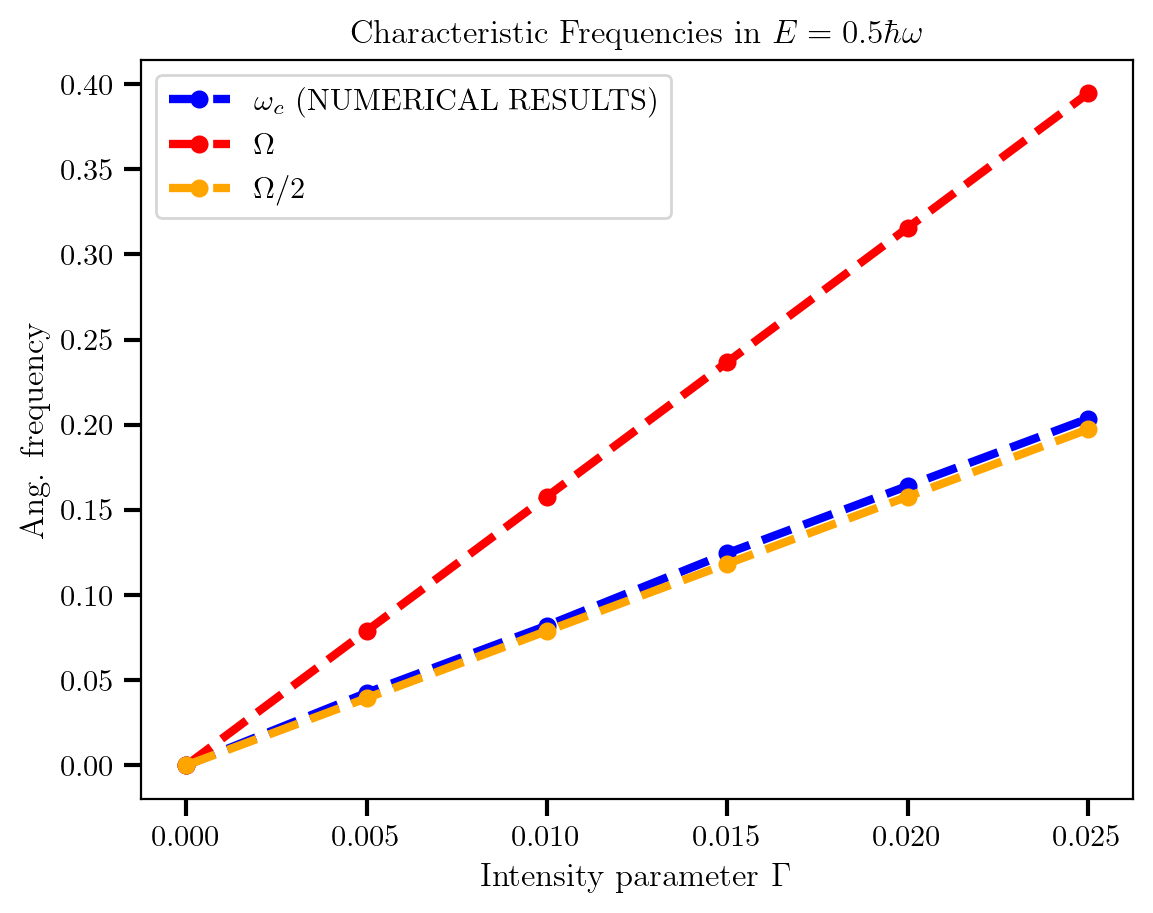

In [50]:
#%% Trying Rabi stuff to see if theoretical results make sense using gap
t = -2.7
Phi0 = 2*np.pi*hbar
if modifier_id == 'circln':
    w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar/2**0.5

else:
     w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar
#w1 = 2*vf*A0/hbar


rep = 1
delta_w = (1-rep)*w
#delta_w = w_laser - gap1_fl/jcl.hbar_fs
rabi_freq = np.sqrt(delta_w**2 + w1**2)
#rabi_freq = 2*vf*A0/jcl.hbar_fs*np.sqrt(1+E**2/(vf**2*A0**2))



fig, ax = plt.subplots(dpi=200)
ax.plot(gamma_list, char_freq[:,3], ls='--', c=color_list[3], marker='.',
        label=f'$\\omega_c$ (NUMERICAL RESULTS)')
ax.plot(gamma_list, rabi_freq, ls='--', c='red', marker='.',
        label=f'$\\Omega$')
ax.plot(gamma_list, rabi_freq/2, ls='--', c='orange', marker='.',
        label=f'$\\Omega/2$')
ax.set_title('Characteristic Frequencies in $E=0.5\\hbar\\omega$')
ax.set_xlabel('Intensity parameter $\\Gamma$')
ax.set_ylabel('Ang. frequency')
ax.legend()

#np.save('Out/char_freqs.npy', char_freq[:,3])